In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
data_test = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
data_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [3]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [4]:
data_train = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
data_train.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


# **EDA for Data Train**

In [5]:
data_train['HomePlanet'].count()

8492

In [6]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
data_train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder 
label_encoder= LabelEncoder()

data_train['Transported'] = label_encoder.fit_transform(data_train['Transported'])
data_train['VIP'] = label_encoder.fit_transform(data_train['VIP'])
data_train['CryoSleep'] = label_encoder.fit_transform(data_train['CryoSleep'])



In [9]:
data_train.dropna(inplace=True) #let's eliminate nan values


In [10]:
data_train.isna().sum() #we're checking the missing values once again

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [11]:
data_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,0
8689,9278_01,Earth,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,0
8690,9279_01,Earth,0,G/1500/S,TRAPPIST-1e,26.0,0,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,1
8691,9280_01,Europa,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,0


In [12]:
#let's transform the categorical data to be numerical data so we can apply the machine learning algorithm into the dataset
data_train['HomePlanet'] = label_encoder.fit_transform(data_train['HomePlanet']) 

In [13]:
data_train.describe()

,HomePlanet,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
count,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000
mean,0.667147,0.394642,28.868933,0.072591,223.040905,479.372606,174.871525,311.801095,301.840415,0.503961
std,0.797556,0.537110,14.550980,0.341040,651.478241,1681.396577,566.074339,1133.397481,1124.847934,0.500020
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,38.000000,0.000000,49.000000,83.000000,28.000000,63.000000,47.000000,1.000000
max,2.000000,2.000000,79.000000,2.000000,9920.000000,29813.000000,12253.000000,22408.000000,20336.000000,1.000000


In [14]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'histogram of HomePlanet Distribution')

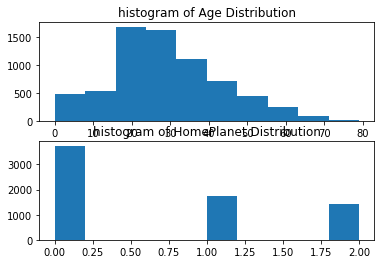

In [15]:
plt.subplot(2,1,1)
plt.hist(data_train['Age'])
plt.title("histogram of Age Distribution")

plt.subplot(2,1,2)
plt.hist(data_train['HomePlanet'])
plt.title("histogram of HomePlanet Distribution")


In [16]:
data_train[data_train["HomePlanet"]==0] #Europe

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
1,0002_01,0,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
4,0004_01,0,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1
5,0005_01,0,0,F/0/P,PSO J318.5-22,44.0,0,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,1
6,0006_01,0,0,F/2/S,TRAPPIST-1e,26.0,0,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,1
8,0007_01,0,0,F/3/S,TRAPPIST-1e,35.0,0,0.0,785.0,17.0,216.0,0.0,Andona Beston,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8681,9270_01,0,1,G/1497/S,55 Cancri e,33.0,0,0.0,0.0,0.0,0.0,0.0,Lan Mckinsond,1
8682,9272_01,0,0,G/1507/P,TRAPPIST-1e,26.0,0,240.0,242.0,510.0,0.0,0.0,Ireene Simson,1
8683,9272_02,0,0,F/1894/P,TRAPPIST-1e,21.0,0,86.0,3.0,149.0,208.0,329.0,Gordo Simson,0
8689,9278_01,0,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,0


In [17]:
data_train[data_train["HomePlanet"]==1] #Earth

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
2,0003_01,1,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,1,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
9,0008_01,1,1,B/1/P,55 Cancri e,14.0,0,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,1
11,0008_03,1,0,B/1/P,55 Cancri e,45.0,0,39.0,7295.0,589.0,110.0,124.0,Wezena Flatic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8686,9275_02,1,0,A/97/P,TRAPPIST-1e,32.0,0,1.0,1146.0,0.0,50.0,34.0,Diram Conable,0
8687,9275_03,1,2,A/97/P,TRAPPIST-1e,30.0,0,0.0,3208.0,0.0,2.0,330.0,Atlasym Conable,1
8688,9276_01,1,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,0
8691,9280_01,1,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,0


In [18]:
data_train[data_train["HomePlanet"]==2] #Mars

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
12,0009_01,2,0,F/1/P,TRAPPIST-1e,32.0,0,73.0,0.0,1123.0,0.0,113.0,Berers Barne,1
18,0016_01,2,1,F/5/P,TRAPPIST-1e,45.0,0,0.0,0.0,0.0,0.0,0.0,Alus Upead,1
31,0028_01,2,0,F/8/P,TRAPPIST-1e,43.0,0,1125.0,0.0,136.0,48.0,0.0,Ceros Mare,0
33,0031_01,2,0,F/9/P,TRAPPIST-1e,47.0,0,214.0,0.0,1411.0,0.0,1229.0,Coobix Datie,1
34,0031_02,2,0,F/9/P,TRAPPIST-1e,2.0,0,0.0,0.0,0.0,0.0,0.0,Cinets Datie,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8654,9231_02,2,0,F/1888/P,TRAPPIST-1e,0.0,0,0.0,0.0,0.0,0.0,0.0,Walls Paie,1
8655,9231_03,2,0,E/592/P,TRAPPIST-1e,22.0,0,0.0,0.0,0.0,0.0,0.0,Cus Paie,0
8660,9239_01,2,0,E/593/P,TRAPPIST-1e,14.0,0,2.0,0.0,918.0,128.0,0.0,Per Minen,0
8661,9241_01,2,0,E/595/P,TRAPPIST-1e,30.0,0,699.0,0.0,600.0,0.0,0.0,Ants Fone,0


In [19]:
data_train["Destination"]

0         TRAPPIST-1e
1         TRAPPIST-1e
2         TRAPPIST-1e
3         TRAPPIST-1e
4         TRAPPIST-1e
            ...      
8688      55 Cancri e
8689    PSO J318.5-22
8690      TRAPPIST-1e
8691      55 Cancri e
8692      TRAPPIST-1e
Name: Destination, Length: 6943, dtype: object

<AxesSubplot:xlabel='Destination', ylabel='Age'>

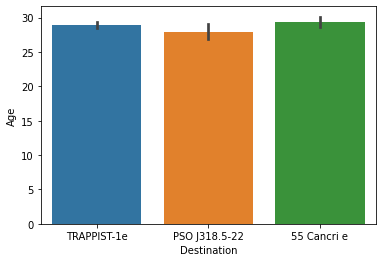

In [20]:
import seaborn as sns

#let's plot the destination vs age 

sns.barplot(x= data_train["Destination"], y= data_train['Age']) 

<AxesSubplot:xlabel='HomePlanet', ylabel='Age'>

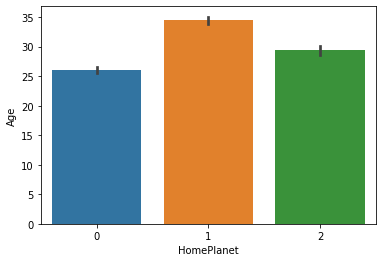

In [21]:
#let's plot homeplanet vs age 
sns.barplot(x= data_train["HomePlanet"], y= data_train['Age']) 

# ****EDA for Data Test****

In [22]:
data_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [23]:
data_test.isna().sum() #Checking NaN values

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [24]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [25]:
data_test['Age'] #There are some NaN Values in "Age" column

0       27.0
1       19.0
2       31.0
3       38.0
4       20.0
        ... 
4272    34.0
4273    42.0
4274     NaN
4275     NaN
4276    43.0
Name: Age, Length: 4277, dtype: float64

In [26]:
#fill NaN value of Age with Mean
mean = data_test['Age'].mean()
data_test['Age'] = data_test['Age'].replace(np.nan, mean)
data_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.000000,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.000000,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.000000,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.000000,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.000000,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.000000,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.000000,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,28.658146,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,28.658146,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [27]:
data_test.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age               0
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [28]:
from sklearn.preprocessing import LabelEncoder 
label_encoder= LabelEncoder()

data_test['HomePlanet'] = label_encoder.fit_transform(data_test['HomePlanet'])
data_test['CryoSleep'] = label_encoder.fit_transform(data_test['CryoSleep'])
data_test['VIP'] = label_encoder.fit_transform(data_test['VIP'])

In [29]:
data_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,0,1,G/3/S,TRAPPIST-1e,27.0,0,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,0,0,F/4/S,TRAPPIST-1e,19.0,0,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,1,1,C/0/S,55 Cancri e,31.0,0,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,1,0,C/1/S,TRAPPIST-1e,38.0,0,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,0,0,F/5/S,TRAPPIST-1e,20.0,0,10.0,0.0,635.0,0.0,0.0,Brence Harperez


Text(0.5, 1.0, 'histogram of HomePlanet Distribution')

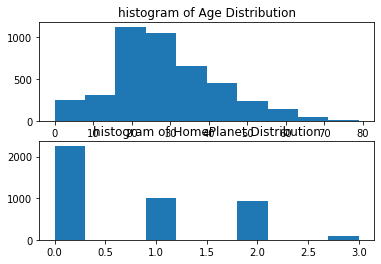

In [30]:
plt.subplot(2,1,1)
plt.hist(data_test['Age'])
plt.title("histogram of Age Distribution")

plt.subplot(2,1,2)
plt.hist(data_test['HomePlanet'])
plt.title("histogram of HomePlanet Distribution")

<AxesSubplot:xlabel='Destination', ylabel='Age'>

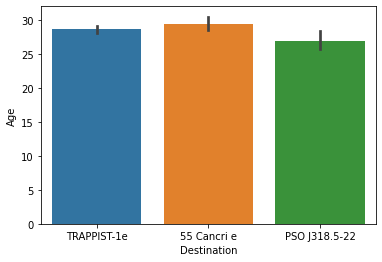

In [31]:
import seaborn as sns

#let's plot the destination vs age 

sns.barplot(x= data_test["Destination"], y= data_test['Age']) 

<AxesSubplot:xlabel='HomePlanet', ylabel='Age'>

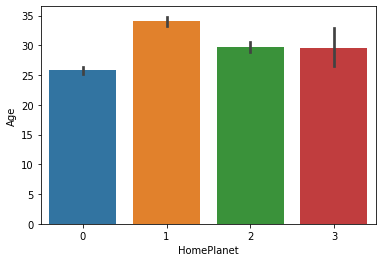

In [32]:
#let's plot homeplanet vs age 
sns.barplot(x= data_test["HomePlanet"], y= data_test['Age']) 

# ****Let's Process the data train and data test

In [33]:
no= np.arange(0,400,1)
no= pd.DataFrame(no)

In [34]:
data_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,B/0/P,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,0,0,F/0/S,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,1,0,A/0/S,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,1,0,A/0/S,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,0,0,F/1/S,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,1,0,A/98/P,55 Cancri e,41.0,1,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,0
8689,9278_01,0,1,G/1499/S,PSO J318.5-22,18.0,0,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,0
8690,9279_01,0,0,G/1500/S,TRAPPIST-1e,26.0,0,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,1
8691,9280_01,1,0,E/608/S,55 Cancri e,32.0,0,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,0


In [35]:
X_Train= data_train.iloc[:, [2,5,6,7,8,9,10,11]].values


In [36]:
#dealing with missing value on integer object
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X_Train)
X_Train = imputer.transform(X_Train)

In [37]:
y_train= data_train['Transported'].values

> * **After doing the EDA, let's predict wheter a passengger will be transported or not by executing the dataset using classification algorthms**
> * **I use 2 classification algorithms to predict the result**
> * **I use classification algorithm because the result of prediction will be classification (Transported(1) or not(0)******

# **first, we will try to predict the transported passengers using decision Tree**

Decision Tree is one of Machine Learning Algorithm classification that we can use to predict something based on dataset that we have

In [38]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_Train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [39]:
X_test= data_test.iloc[:, [2,5,6,7,8,9,10,11]].values

In [40]:
#dealing with missing value on integer object
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X_test)
X_test = imputer.transform(X_test)

In [41]:
prediction = classifier.predict(X_test)

In [42]:
print("prediction result =", prediction)
print("training data = ", y_train)



prediction result = [1 0 1 ... 1 1 1]
training data =  [0 1 0 ... 1 0 1]


# **second, we will try to predict the transported passengers with random forest classifier**

Random Forest one of Machine Learning algorithm classification that we can use to make prediction.


In [43]:
from sklearn.ensemble import RandomForestClassifier
classifier_2 = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier_2.fit(X_Train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [44]:
prediction_2= classifier_2.predict(X_test)

In [45]:
print("prediction result =", prediction_2)
print("training data = ", y_train)

prediction result = [1 0 1 ... 1 0 1]
training data =  [0 1 0 ... 1 0 1]


(array([2107.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2170.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

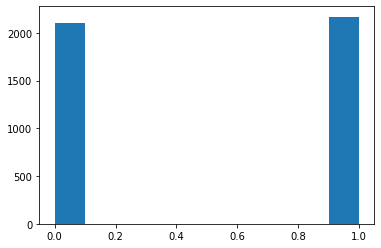

In [46]:
plt.hist(prediction_2)

(array([3444.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        3499.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

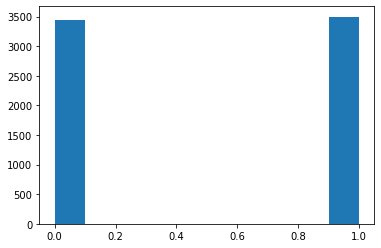

In [47]:
plt.hist(y_train)

In [48]:
my_submission_titanic= pd.DataFrame({'PassengerId':data_test.PassengerId, 'Transported': prediction_2 })

my_submission_titanic.to_csv('submission.csv', index=False)

In [49]:
my_submission_titanic_2= pd.DataFrame({'PassengerId':data_test.PassengerId, 'Transported': prediction})

my_submission_titanic_2.to_csv('submission.csv', index=False)